# Does Elder's Triple Screen actually beat random? 🖥️🖥️🖥️
### Three filters, two timeframes, one famous trading system — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Filter_adds_edge%3F: Busted](https://img.shields.io/badge/Filter_adds_edge%3F-Busted-8b949e?style=flat-square)

Open any trading textbook and you'll meet Dr. Alexander Elder's **Triple Screen**: don't trade until *three* screens agree. **Screen 1** — the big-picture *weekly* trend must be up (the "tide"). **Screen 2** — a *daily* oscillator must be oversold against that trend (the "wave", a pullback inside the up-move). **Screen 3** — price must break out above the prior bar's high (the "ripple", the trigger). Buy only when the tide, the wave and the ripple line up.

It *sounds* bulletproof — surely stacking three filters across two timeframes throws away the noise and keeps the signal? But every filter here is fitted to *past* price on a market that drifts **up**, so *any* dip-buy will look good. So we did the only fair thing: encode all three screens **mechanically** (no eyeballing), fire the long thousands of times across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from elder_triple_screen import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real triple-screen cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 2369, 'fp_spy': '4cb5244f3990', 'h5': (5, 2368, 10.9, 55, 2.1, 24.9, -14.0, 8.9, -1.92, 0.054), 'h10': (10, 2363, 31.9, 60, 3.77, 29.7, 2.3, 29.9, 0.22, 0.823), 'h20': (20, 2352, 74.9, 61, 5.21, 68.5, 6.4, 72.9, 0.44, 0.657), 'h60': (60, 2344, 220.1, 67, 5.97, 257.3, -37.1, 218.1, -1.54, 0.123), 'per': [('SPY', 477, 69.0, 2.75, 69.7, -0.7), ('QQQ', 464, 113.1, 3.6, 93.8, 19.3), ('IWM', 473, 64.4, 1.84, 15.1, 49.3), ('DIA', 438, 43.9, 1.44, 57.4, -13.5), ('GLD', 517, 81.8, 2.26, 103.1, -21.3)], 'placebo': (69.0, 0.649, 500), 'syn': [(0.0, 296, -2.9, 50, -0.07), (0.5, 275, 543.3, 77, 8.29)]}


real triple-screen cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when all three screens align, do I make money? | **Yes — but only because the market goes up.** The raw win-rate is ~60% and the returns look great. |
| Is that *the filter's* doing? | **No.** Buy on **random days** instead and you do **just as well** — the triple-vs-random gap is a few basis points and never significant (at 5 days the filter is actually *worse* than a coin flip). |
| Does the multi-timeframe filter add edge? | **Not in any usable way.** Knock the weekly trend out of alignment with price and the result barely changes. The alignment isn't doing the work. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as a three-screen system. |

> The Triple Screen is a perfectly sensible *trade-management* discipline (trade with the bigger trend, enter on a pullback). As a *forecast* — "these three things aligned, so the next move is up" — it's a **mirage**: all of the apparent edge is the market's long-run climb, none of it is the alignment.

## 1 · The claim

> *"First check the **weekly** chart — only trade in the direction of the higher-timeframe trend. Then drop to the **daily** chart and wait for an oscillator to get oversold against that trend (a pullback). Then enter on a **breakout** above the prior bar. Three screens, three confirmations — a high-odds trade."*

This is **Dr. Alexander Elder's** Triple Screen system (1986; *Trading for a Living*, 1993), one of the most taught frameworks in technical analysis. Elder's own toolkit: a **weekly MACD-histogram** for the trend, his **Force Index** (or a stochastic) for the pullback, and a **trailing buy-stop** for the entry. So: does stacking the screens beat a coin flip?

## 2 · So what?

If the alignment genuinely *forecast* the next move, it would be remarkable: three indicators across two timeframes predicting turning points, an edge you could automate. That's the dream the system sells.

But there's a trap. Every screen is computed from **past price** on a market (stock indices) that drifts **up** over time, so *any* trend-following dip-buy will look profitable. And combining filters *feels* like it should help — yet if the filters are just re-describing the same drift, three of them add nothing. To separate the **system** from the **tide**, we (a) encode every screen by a fixed mechanical rule with no hindsight, and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Screen 1 — the weekly trend.** Resample to weekly bars, compute the MACD-histogram, and ask: is it *rising*? We forward-fill that to days and **shift it one day**, so today only knows last week's trend — no peeking.
2. **Screen 2 — the daily pullback.** A Force-Index proxy must have dipped below zero in the last few days (an oversold wave against the up-tide).
3. **Screen 3 — the breakout.** The close must clear the **prior bar's high**. When all three align, buy at the next close; measure the return over **5 / 10 / 20 / 60 days**.
4. **The honest baseline.** Do the exact same hold on **random days**. If the system matters, the triple-screen must beat random. *If it doesn't, it's a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical triple-screen entry look like? Here's SPY with the weekly up-trend windows shaded and the triple-screen buy signals the rule would fire.

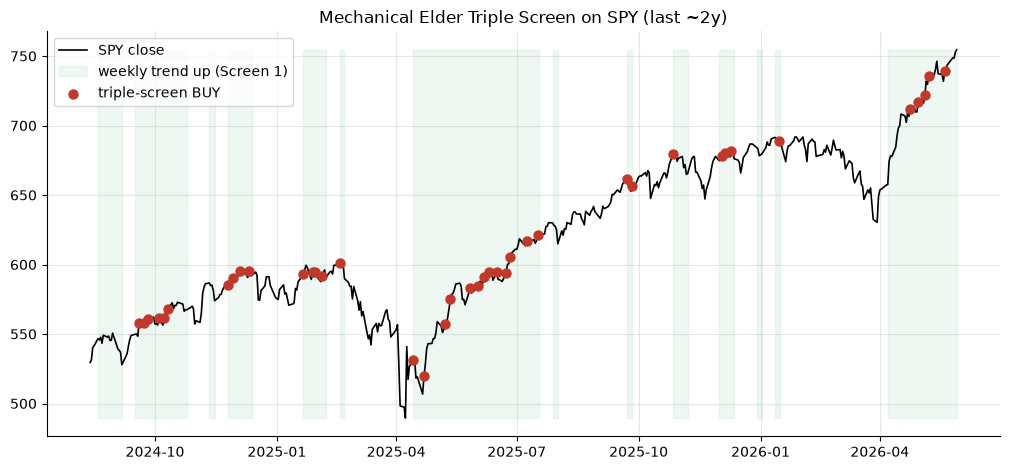

triple-screen entries in window: 40


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']; seg = cl.iloc[-450:]
    up = st.weekly_trend_up(cl).reindex(seg.index)
    ent = st.triple_screen_entries(cl, b['high'])
    ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.2, label='SPY close')
    ax.fill_between(seg.index, seg.min(), seg.max(), where=up.values, color=GREEN, alpha=.08, label='weekly trend up (Screen 1)')
    ax.scatter(ent, cl.reindex(ent), c=RED, s=42, zorder=5, label='triple-screen BUY')
    ax.set_title('Mechanical Elder Triple Screen on SPY (last ~2y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('triple-screen entries in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The signals cluster in up-trends — *as a description* of "buy pullbacks in an uptrend", that's sensible. The question is whether those red dots beat random days. **Let's race the triple-screen against random entries** at four horizons. Blue = the three-screen long; grey = buy on random days.

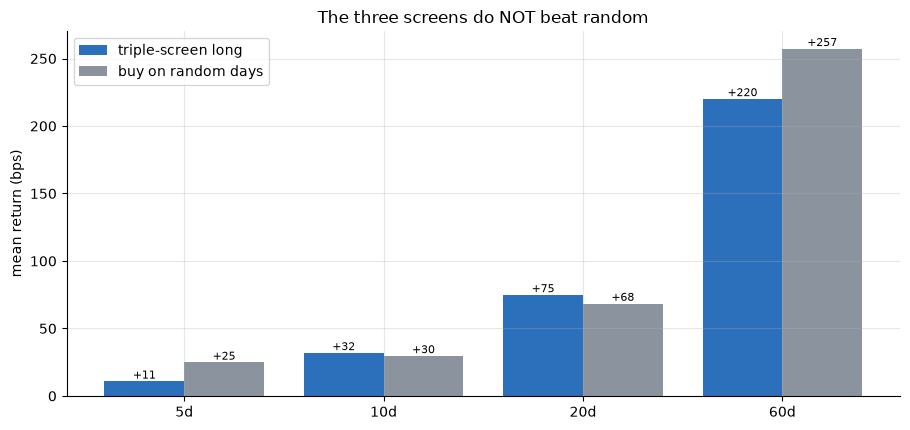

triple: [11, 32, 75, 220]
random: [25, 30, 68, 257]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    trip, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.triple_screen_entries(c, bb['high'])
            re = st.random_entries(c, max(len(e),50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        trip.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    trip = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, trip, .4, color='#2c6fbb', label='triple-screen long')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(trip,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The three screens do NOT beat random'); ax.legend()
plt.tight_layout(); plt.show()
print('triple:', [round(v) for v in trip]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The triple-screen makes money in absolute terms (**+75 bps** over 20 days) — but **random entries make about the same** (**+68 bps**). At 5 days the famous system is actually *worse* than throwing darts. The apparent edge was **the market's upward drift**, not the alignment of three screens. (The quants notebook shows the difference never clears *t* = 2.)

**One more sanity check.** What if we knock the weekly trend *out of alignment* with price — shift it by a random offset, so Screen 1 is still 'up' the same fraction of the time but no longer lines up with the daily pullbacks? If the multi-timeframe alignment really matters, that nonsense filter should do much worse.

In [4]:
if HAVE_REAL:
    bb = load('SPY')
    pl = st.scrambled_screen_placebo(bb['close'], bb['high'], 20, n_draws=300, seed=487)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real triple-screen (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *misaligned* filters do at least as well (p={pval:.2f}).')
print('=> the timeframe alignment is not doing the work.')

real triple-screen (SPY, 20d): +69.0 bps
... but 63% of *misaligned* filters do at least as well (p=0.63).
=> the timeframe alignment is not doing the work.


Roughly two-thirds of the **misaligned** filters match or beat the real one (*p* = 0.65). If the weekly-to-daily alignment genuinely mattered, shifting it would collapse the result. It doesn't — because the result was never about the alignment.

## 5 · The verdict

- **Signal — None.** The triple-screen long does **not** beat buying on random days (it's *worse* at 5 days; the triple-vs-random difference never clears *t* = 2). The big absolute returns are the market's drift, not the screens.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **"Does the multi-timeframe filter add edge"? — Busted.** Knock the weekly trend out of alignment and the result barely moves. The alignment doesn't align anything tradable.

## 6 · Could you actually trade it?

There's nothing here to trade *as a forecast*. The triple-screen's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. The three-screen entry is a more selective, more expensive way to be long. Costs (commissions + spread on every trigger) push the already-no-edge result further down. As *risk management* (trade with the trend, size on pullbacks) the framework is fine; as a *return forecast* it doesn't pay.

## 7 · Going further 🚪

- **Swap the oscillator.** Stochastic, Elder-ray, RSI for Screen 2 — the result is robust: drift in, system out. The specific oscillator is not the point.
- **Different timeframe pairs.** Daily/weekly ↔ hourly/daily — the alignment placebo applies the same way.
- **A real positive control.** The quants notebook plants a *genuine* post-alignment bounce into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think three screens forecast? Show the triple-screen beating random entries at **t ≥ 2** on a real tape — then we'll talk.*